<a href="https://colab.research.google.com/github/NKY1617/NaveenYadav_64061/blob/main/Cloud_Utilization_Descriptive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# -----------------------------
# Configuration
# -----------------------------
NUM_SESSIONS = 10000
START_DATE = datetime(2025, 1, 1)
END_DATE = datetime(2025, 12, 20)

regions = ["us-central1", "us-east1", "us-west1"]
workload_types = [
    "Data Analysis", "ML Training", "Deep Learning",
    "ETL", "Visualization", "Data Cleaning"
]

# Monthly seasonality multiplier
MONTH_SEASONALITY = {
    1: 0.85,   # January (low)
    2: 1.15,   # February (medium-high)
    3: 1.30,   # March (peak)
    4: 1.10,   # April
    5: 1.05,   # May
    6: 0.95,   # June
    7: 0.80,   # July (summer dip)
    8: 0.82,   # August
    9: 0.90,   # September (back to school/work)
    10: 1.00,  # October
    11: 1.10,  # November
    12: 1.20   # December (end of year push)
}

# Cost rates (synthetic but realistic)
CPU_COST_PER_MIN = 0.006
GPU_COST_PER_MIN = {
    "T4": 0.02,
    "P100": 0.035,
    "A100": 0.06
}

GPU_PROB_BY_HOUR = {
    "peak": 0.65,
    "off_peak": 0.35
}

# -----------------------------
# Helper Functions
# -----------------------------
def random_datetime(start, end):
    delta = end - start
    return start + timedelta(seconds=random.randint(0, int(delta.total_seconds())))

def is_peak_hour(hour):
    return 9 <= hour <= 21

def efficiency_score(cpu, gpu, idle):
    score = (cpu * 0.4) + (gpu * 0.5) - (idle * 0.3)
    return round(max(45, min(100, score)), 2)

# -----------------------------
# Generate Data
# -----------------------------
data = []

for i in range(1, NUM_SESSIONS + 1):
    session_dt = random_datetime(START_DATE, END_DATE)
    month_factor = MONTH_SEASONALITY[session_dt.month]

    peak = is_peak_hour(session_dt.hour)

    # Duration influenced by seasonality & peak hours
    base_duration = random.randint(25, 180)
    duration = int(base_duration * month_factor * (1.2 if peak else 0.8))

    # Compute type decision
    compute_type = (
        "GPU"
        if random.random() < GPU_PROB_BY_HOUR["peak" if peak else "off_peak"]
        else "CPU"
    )

    if compute_type == "GPU":
        gpu_type = random.choices(
            ["T4", "P100", "A100"], weights=[0.5, 0.3, 0.2]
        )[0]
        avg_gpu_util = random.randint(65, 95)
        cost = duration * GPU_COST_PER_MIN[gpu_type]
    else:
        gpu_type = "None"
        avg_gpu_util = 0
        cost = duration * CPU_COST_PER_MIN

    avg_cpu_util = random.randint(40, 85 if peak else 70)
    idle_time = random.randint(5, int(duration * (0.25 if peak else 0.35)))
    ram_used = round(random.uniform(6, 32), 1)
    disk_used = round(random.uniform(3, 30), 1)

    eff_score = efficiency_score(avg_cpu_util, avg_gpu_util, idle_time)

    data.append({
        "session_id": f"S{i:04d}",
        "user_plan": "Pro",
        "session_date": session_dt.date(),
        "session_hour": session_dt.hour,
        "is_peak_hour": peak,
        "session_duration_minutes": duration,
        "compute_type": compute_type,
        "gpu_type": gpu_type,
        "avg_cpu_utilization_pct": avg_cpu_util,
        "avg_gpu_utilization_pct": avg_gpu_util,
        "ram_used_gb": ram_used,
        "disk_used_gb": disk_used,
        "estimated_cost_usd": round(cost, 2),
        "workload_type": random.choice(workload_types),
        "idle_time_minutes": idle_time,
        "region": random.choice(regions),
        "efficiency_score": eff_score
    })

# -----------------------------
# Create DataFrame & Export
# -----------------------------
df = pd.DataFrame(data)
df.to_csv("colab_cloud_utilization_seasonal_1000_sessions.csv", index=False)

print("Seasonal dataset generated successfully!")
print(df.head())

Seasonal dataset generated successfully!
  session_id user_plan session_date  session_hour  is_peak_hour  \
0      S0001       Pro   2025-02-21             1         False   
1      S0002       Pro   2025-07-26            10          True   
2      S0003       Pro   2025-05-25            15          True   
3      S0004       Pro   2025-04-21             8         False   
4      S0005       Pro   2025-09-05            12          True   

   session_duration_minutes compute_type gpu_type  avg_cpu_utilization_pct  \
0                       157          GPU     P100                       43   
1                        34          CPU     None                       73   
2                       129          CPU     None                       40   
3                       111          CPU     None                       45   
4                        43          GPU       T4                       83   

   avg_gpu_utilization_pct  ram_used_gb  disk_used_gb  estimated_cost_usd  \
0         

In [27]:
from google.colab import files

files.download("colab_cloud_utilization_seasonal_1000_sessions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***Objective: Perform descriptive analytics on cloud utilization data to understandresource usage patterns, cost drivers, peak-hour demand, and efficiency using Python-based data analysis and visualization.***


In [28]:
df['session_duration_hours'] = df['session_duration_minutes'] / 60
print("Session duration in hours calculated successfully. Here are the first 5 rows:")
print(df[['session_id', 'session_duration_minutes', 'session_duration_hours']].head())

Session duration in hours calculated successfully. Here are the first 5 rows:
  session_id  session_duration_minutes  session_duration_hours
0      S0001                       157                2.616667
1      S0002                        34                0.566667
2      S0003                       129                2.150000
3      S0004                       111                1.850000
4      S0005                        43                0.716667


Data Preparation (Feature Engineering)

In [29]:
# Session duration in hours
df['cost_per_hour'] = df['estimated_cost_usd'] / df['session_duration_hours']
print("Cost per hour calculated successfully. Here are the first 5 rows with the new column:")
print(df[['session_id', 'estimated_cost_usd', 'session_duration_hours', 'cost_per_hour']].head())

Cost per hour calculated successfully. Here are the first 5 rows with the new column:
  session_id  estimated_cost_usd  session_duration_hours  cost_per_hour
0      S0001                5.50                2.616667       2.101911
1      S0002                0.20                0.566667       0.352941
2      S0003                0.77                2.150000       0.358140
3      S0004                0.67                1.850000       0.362162
4      S0005                0.86                0.716667       1.200000


In [30]:
# Idle time ratio
df['idle_time_ratio'] = df['idle_time_minutes'] / df['session_duration_minutes']
print("Idle Time Ratio calculated successfully. Here are the first 5 rows with the new column:")
print(df[['session_id', 'idle_time_minutes', 'session_duration_minutes', 'idle_time_ratio']].head())

Idle Time Ratio calculated successfully. Here are the first 5 rows with the new column:
  session_id  idle_time_minutes  session_duration_minutes  idle_time_ratio
0      S0001                 26                       157         0.165605
1      S0002                  8                        34         0.235294
2      S0003                 29                       129         0.224806
3      S0004                 22                       111         0.198198
4      S0005                  5                        43         0.116279


In [41]:
# Convert date column
df["session_date"] = pd.to_datetime(df["session_date"])

# Extract month & weekday
df["month"] = df["session_date"].dt.month_name()
df["weekday"] = df["session_date"].dt.day_name()

# Define the order for months to ensure chronological plotting
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

df.describe()

,session_date,session_hour,session_duration_minutes,avg_cpu_utilization_pct,avg_gpu_utilization_pct,ram_used_gb,disk_used_gb,estimated_cost_usd,idle_time_minutes,efficiency_score,session_duration_hours,cost_per_hour,idle_time_ratio
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2025-06-27 17:57:15.840000,11.447600,104.559700,59.038000,41.026300,19.127540,16.606360,2.147230,17.307200,52.117170,1.742662,1.182072,0.179118
min,2025-01-01 00:00:00,0.000000,16.000000,40.000000,0.000000,6.000000,3.000000,0.100000,5.000000,45.000000,0.266667,0.347368,0.019608
25%,2025-04-02 00:00:00,5.000000,61.000000,49.000000,0.000000,12.600000,9.900000,0.560000,8.000000,45.000000,1.016667,0.360000,0.117647
50%,2025-06-29 00:00:00,11.000000,99.000000,58.000000,65.000000,19.300000,16.700000,1.065000,14.000000,45.000000,1.650000,1.200000,0.178122
75%,2025-09-24 00:00:00,18.000000,141.000000,68.000000,80.000000,25.800000,23.500000,2.940000,23.000000,59.000000,2.350000,2.100000,0.234375
max,2025-12-19 00:00:00,23.000000,279.000000,85.000000,95.000000,32.000000,30.000000,15.960000,66.000000,80.000000,4.650000,3.600000,0.350000
std,NaN,6.967906,54.058996,12.137153,40.490806,7.565596,7.849651,2.459997,10.986378,8.680303,0.900983,1.039978,0.078645


Descriptive Analytics (Numerical Summary)

In [32]:
summary_metrics = {
    "Total Sessions": len(df),
    "Total Cost ($)": df["estimated_cost_usd"].sum(),
    "Avg Cost per Session ($)": df["estimated_cost_usd"].mean(),
    "Avg CPU Utilization (%)": df["avg_cpu_utilization_pct"].mean(),
    "Avg GPU Utilization (%)": df["avg_gpu_utilization_pct"].mean(),
    "Avg Efficiency Score": df["efficiency_score"].mean()
}

pd.DataFrame(summary_metrics, index=["Value"])


,Total Sessions,Total Cost ($),Avg Cost per Session ($),Avg CPU Utilization (%),Avg GPU Utilization (%),Avg Efficiency Score
Value,10000,21472.3,2.14723,59.038,41.0263,52.11717


Visualization 1: Monthly Cost Trend (Seasonality)

/tmp/ipython-input-3445559169.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_cost = df.groupby("month")["estimated_cost_usd"].sum()


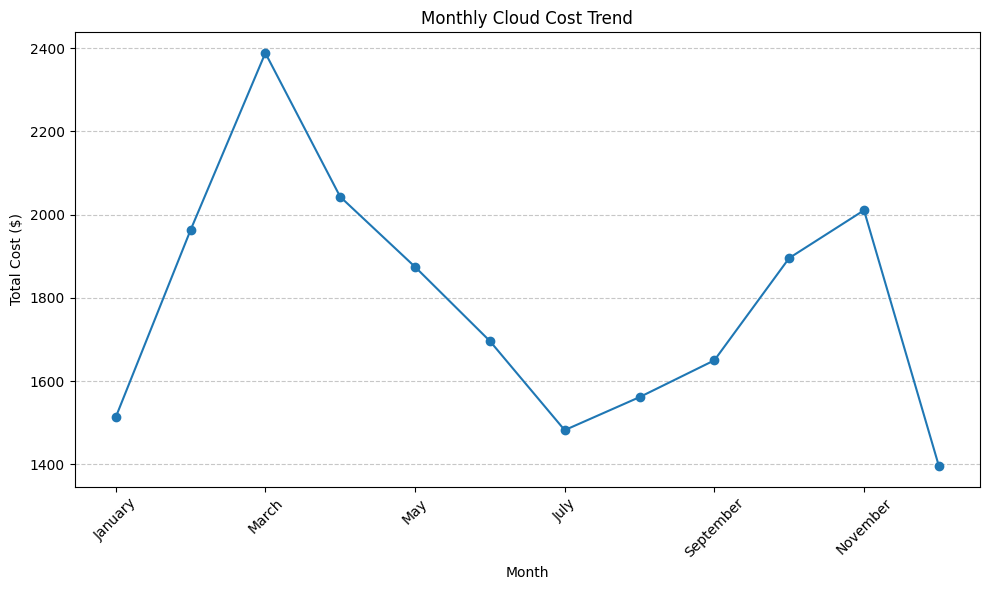

In [42]:
import matplotlib.pyplot as plt

monthly_cost = df.groupby("month")["estimated_cost_usd"].sum()

plt.figure(figsize=(10,6))
monthly_cost.plot(kind="line", marker="o")
plt.title("Monthly Cloud Cost Trend")
plt.ylabel("Total Cost ($)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Visualization 2: Cost by Compute Type (CPU vs GPU)

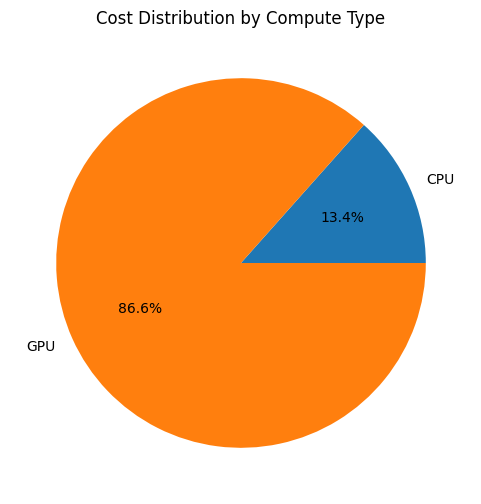

In [44]:
plt.figure(figsize=(6,6))
df.groupby("compute_type")["estimated_cost_usd"].sum().plot(
    kind="pie", autopct="%1.1f%%"
)
plt.title("Cost Distribution by Compute Type")
plt.ylabel("")
plt.show()


Visualization 3: Peak vs Off-Peak Cost Comparison

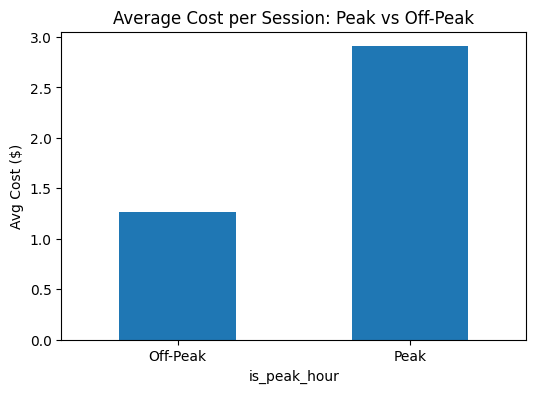

In [45]:
peak_cost = df.groupby("is_peak_hour")["estimated_cost_usd"].mean()

plt.figure(figsize=(6,4))
peak_cost.plot(kind="bar")
plt.title("Average Cost per Session: Peak vs Off-Peak")
plt.ylabel("Avg Cost ($)")
plt.xticks([0,1], ["Off-Peak", "Peak"], rotation=0)
plt.show()


**Visualization 4: Resource Utilization Analysis**

CPU vs GPU Utilization

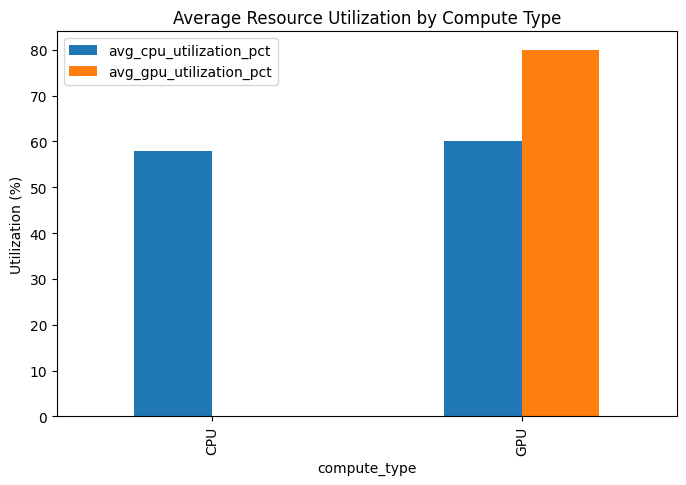

In [46]:
util_df = df.groupby("compute_type")[[
    "avg_cpu_utilization_pct",
    "avg_gpu_utilization_pct"
]].mean()

util_df.plot(kind="bar", figsize=(8,5))
plt.title("Average Resource Utilization by Compute Type")
plt.ylabel("Utilization (%)")
plt.show()

***Visualization 5: Hourly Usage Pattern (Peak Hours)***

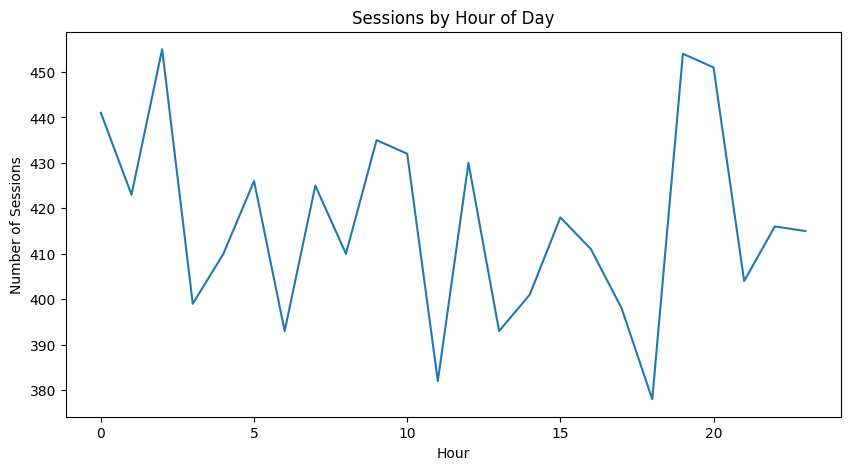

In [47]:
hourly_sessions = df.groupby("session_hour").size()

plt.figure(figsize=(10,5))
hourly_sessions.plot(kind="line")
plt.title("Sessions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Sessions")
plt.show()

Visualization 6: Cost vs Idle Time (Efficiency Detection)

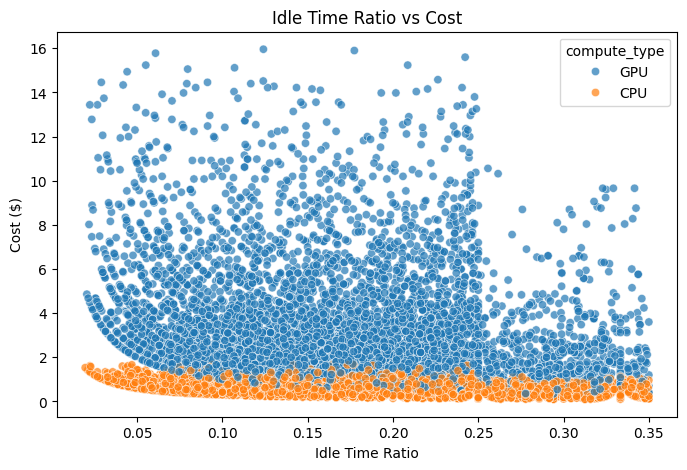

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="idle_time_ratio",
    y="estimated_cost_usd",
    hue="compute_type",
    alpha=0.7
)
plt.title("Idle Time Ratio vs Cost")
plt.xlabel("Idle Time Ratio")
plt.ylabel("Cost ($)")
plt.show()

***Visualization 7: Heatmap (Month × Hour Cost)***

/tmp/ipython-input-1073562272.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


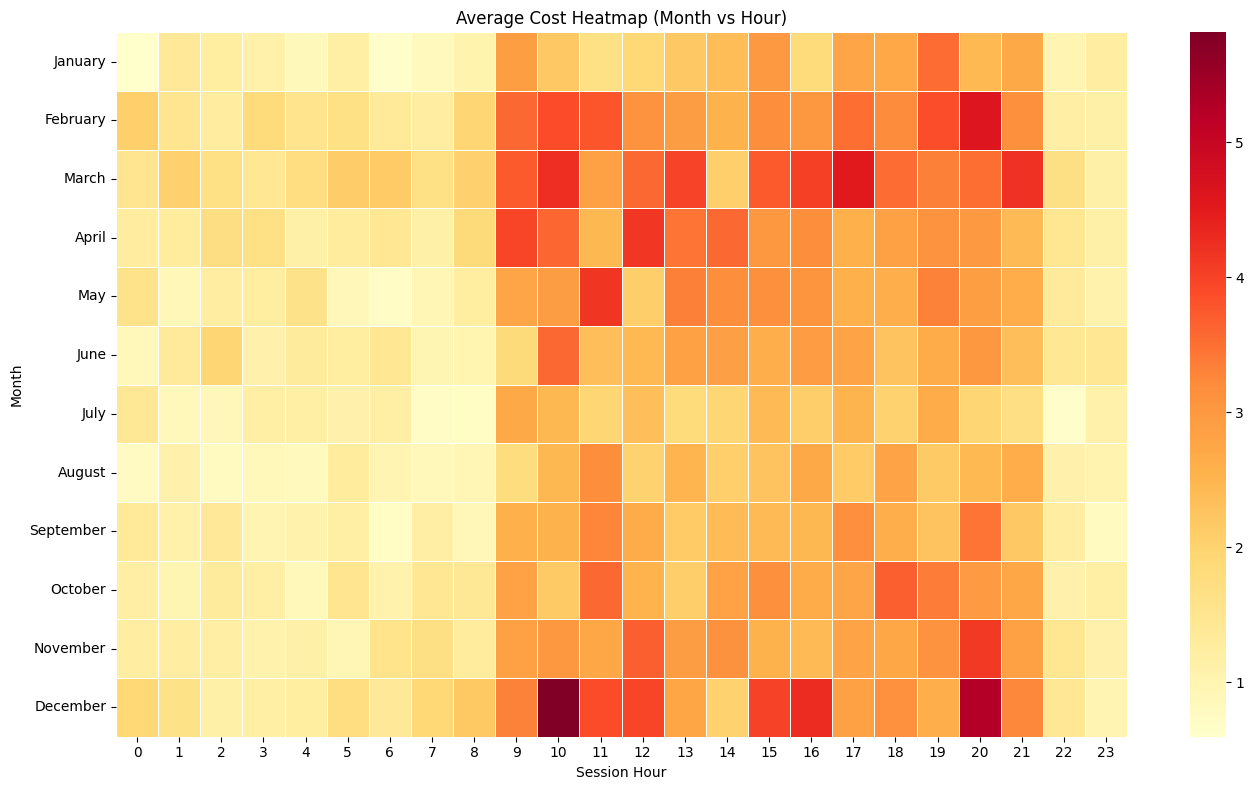

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(
    values="estimated_cost_usd",
    index="month",
    columns="session_hour",
    aggfunc="mean"
)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5)
plt.title("Average Cost Heatmap (Month vs Hour)")
plt.xlabel("Session Hour")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

***Key Descriptive Findings***

In [50]:
findings = [
    "GPU-based sessions account for the majority of total cloud costs.",
    "Peak hours show higher utilization with lower idle time ratios.",
    "March exhibits the highest cost due to seasonal workload increase.",
    "Several high-cost sessions show elevated idle time, indicating inefficiencies."
]

pd.DataFrame(findings, columns=["Key Insights"])


,Key Insights
0,GPU-based sessions account for the majority of...
1,Peak hours show higher utilization with lower ...
2,March exhibits the highest cost due to seasona...
3,Several high-cost sessions show elevated idle ...
